In [1]:
import pandas as pd
import sys
sys.path.append('..')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.core.ablation_trainer import AblationTrainer

In [3]:
# Models đại diện cho ablation
from src.model.random_forest_classifier import RandomForestClassifierModel
from src.model.xgb_classifier import XGBClassifierModel
from src.model.xgbrf_classifier import XGBRFClassifierModel
from src.model.hist_gradient_boosting_classifier import HistGradientBoostingClassifierModel
from src.model.ridge_regression import RidgeRegressionModel
from src.model.lasso_regression import LassoRegressionModel
from src.model.svm_classifier import SVMClassifierModel


RANDOM_STATE = 42
RESULTS_DIR  = Path('../results/ablation')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup done!")

Setup done!


In [4]:
# ================================================================== #
# CELL 2 — Load Data
# ================================================================== #

# Processed data — dùng cho Ablation 1 và 3
train_tree   = pd.read_csv('../data/processed/tree/train.csv')
train_linear = pd.read_csv('../data/processed/linear/train.csv')
test_tree    = pd.read_csv('../data/processed/tree/test.csv')
test_linear  = pd.read_csv('../data/processed/linear/test.csv')

# Raw train — dùng cho Ablation 2 (preprocessor chạy lại)
raw_train = pd.read_csv('../data/splits/train.csv')

print(f"train_tree   : {train_tree.shape}")
print(f"train_linear : {train_linear.shape}")
print(f"raw_train    : {raw_train.shape}")
print(f"\nClass distribution (train_tree):")
print(train_tree['risk_class'].value_counts())

train_tree   : (2370, 18)
train_linear : (2370, 38)
raw_train    : (2370, 18)

Class distribution (train_tree):
risk_class
Low       1595
Medium     459
High       316
Name: count, dtype: int64


In [5]:
ablation = AblationTrainer(
    n_splits=5, n_repeats=3, random_state=RANDOM_STATE
)
MODELS = {
    'RF'    : RandomForestClassifierModel(),
    'XGB'   : XGBClassifierModel(),
    'Ridge' : RidgeRegressionModel(),
    'SVM'   : SVMClassifierModel()
}

print("AblationTrainer initialized!")
print(f"CV: {ablation.n_splits} folds × {ablation.n_repeats} repeats "
      f"= {ablation.n_splits * ablation.n_repeats} scores per config")

AblationTrainer initialized!
CV: 5 folds × 3 repeats = 15 scores per config


In [9]:
# ================================================================== #
# CELL 4 — ABLATION 1: Imbalance Handling
# ================================================================== #
print("\n" + "="*60)
print("ABLATION 1: Imbalance Handling")
print("="*60)
print("""
Mục đích: So sánh SMOTE, class weight và các mức risk weight
Models  : RF, Ridge, Lasso, XGBRF, HistGB, SVM
Data    : raw_train; preprocessing được fit riêng trong từng fold CV
""")

# Cho phép chạy lại cell mà không giữ kết quả Ablation 1 cũ.
ablation.results = [
    result for result in ablation.results
    if result.experiment != 'imbalance'
]

results_imbalance = ablation.run_ablation_imbalance(
    raw_train_df = raw_train,
    models       = {
        'RIDGE' : RidgeRegressionModel(),
        'Lasso' : LassoRegressionModel(),
        'SVM'   : SVMClassifierModel(),
        'RF'    : RandomForestClassifierModel(),
    }
)




ABLATION 1: Imbalance Handling

Mục đích: So sánh SMOTE, class weight và các mức risk weight
Models  : RF, Ridge, Lasso, XGBRF, HistGB, SVM
Data    : raw_train; preprocessing được fit riêng trong từng fold CV


ABLATION 1 — Imbalance Handling

[PipelineB] fitting on 1,896 rows...
  use_skew=True, use_scale=True, use_ohe=True, fe_groups=['G1', 'G2', 'G3', 'G4']
  Yeo-Johnson transforms:
    'elevation_m': skew=1.754 → λ=0.4014
    'storm_drain_proximity_m': skew=1.092 → λ=0.3527
    'historical_rainfall_intensity_mm_hr': skew=1.433 → λ=0.0054
    'return_period_years': skew=1.978 → λ=-0.2532
    'G1_infra_vuln': skew=3.126 → λ=0.0780
    'G2_rain_x_return': skew=3.556 → λ=-0.1069
    'G3_soil_x_rainfall': skew=1.816 → λ=0.4152
[PipelineB] done — 34 features

[PipelineB] fitting on 1,896 rows...
  use_skew=True, use_scale=True, use_ohe=True, fe_groups=['G1', 'G2', 'G3', 'G4']
  Yeo-Johnson transforms:
    'elevation_m': skew=1.782 → λ=0.4026
    'storm_drain_proximity_m': skew=1.156 → λ

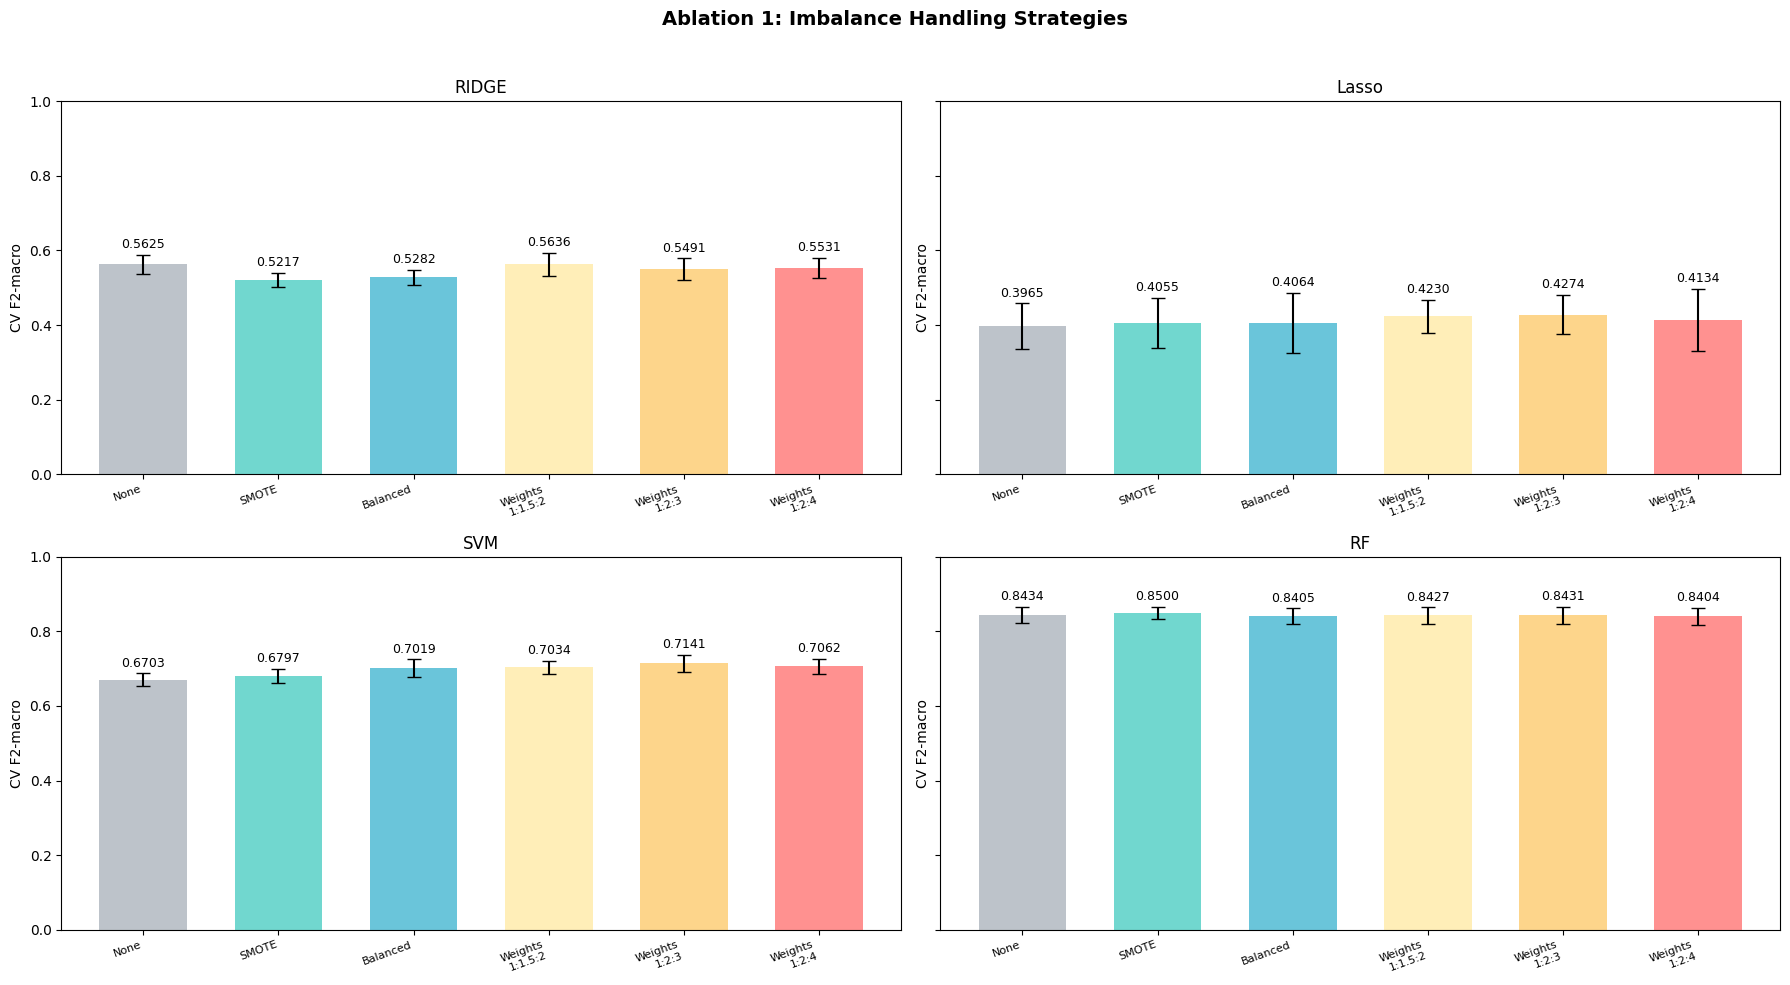

In [12]:
df_imbalance = ablation.to_dataframe()
df_imbalance = df_imbalance[df_imbalance['experiment'] == 'imbalance']

models = ['RIDGE', 'Lasso', 'SVM', 'RF']
configs_order = [
    'none', 'SMOTE', 'class_weight_balanced',
    'weights_1_1.5_2', 'weights_1_2_3', 'weights_1_2_4',
]
label_map = {
    'none': 'None',
    'SMOTE': 'SMOTE',
    'class_weight_balanced': 'Balanced',
    'weights_1_1.5_2': 'Weights\n1:1.5:2',
    'weights_1_2_3': 'Weights\n1:2:3',
    'weights_1_2_4': 'Weights\n1:2:4',
}
color_map = {
    'none': '#ADB5BD',
    'SMOTE': '#4ECDC4',
    'class_weight_balanced': '#45B7D1',
    'weights_1_1.5_2': '#FFEAA7',
    'weights_1_2_3': '#FDCB6E',
    'weights_1_2_4': '#FF7675',
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True)
axes = axes.flatten()

fig.suptitle('Ablation 1: Imbalance Handling Strategies',
             fontsize=14, fontweight='bold')

for ax, model_name in zip(axes, models):

    sub = df_imbalance[df_imbalance['model'] == model_name].copy()

    if sub.empty:
        ax.set_visible(False)
        continue

    sub = (sub.drop_duplicates('config', keep='last')
              .set_index('config').reindex(configs_order).reset_index())
    x = np.arange(len(configs_order))

    bars = ax.bar(
        x,
        sub['cv_f2_mean'],
        yerr=sub['cv_f2_std'],
        color=[color_map[config] for config in configs_order],
        alpha=0.8,
        capsize=5,
        width=0.65
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [label_map[config] for config in configs_order],
        rotation=20, ha='right', fontsize=8
    )
    ax.set_title(model_name, fontsize=12)
    ax.set_ylabel('CV F2-macro')
    ax.set_ylim(0, 1)

    for bar, mean, std in zip(
        bars,
        sub['cv_f2_mean'],
        sub['cv_f2_std']
    ):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.01,
            f'{mean:.4f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# Hide unused subplot
for i in range(len(models), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    RESULTS_DIR / 'ablation1_imbalance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [21]:
# ================================================================== #
# CELL 6 — ABLATION 2: Feature Engineering
# ================================================================== #
print("\n" + "="*60)
print("ABLATION 2: Feature Engineering Groups")
print("="*60)
print("""
Mục đích: Tìm group features nào đóng góp nhiều nhất
Configs :
  baseline → chỉ 5 numeric gốc + categorical
  +G1      → + G1_infra_vuln
  +G2      → + G2_rain_x_return
  +G3      → + G3_soil_x_rainfall
  +G4      → + G4_is_very_low_elev
  ALL      → tất cả G1+G2+G3+G4
Models  : RF, XGB, Ridge
Data    : raw_train (preprocessor chạy lại cho từng config)
""")

results_features = ablation.run_ablation_features(
    raw_train_df = raw_train,
    models       = {
        'Ridge': RidgeRegressionModel(),
        'Lasso': LassoRegressionModel(),
        'SVM'   : SVMClassifierModel(),
        'RF'   : RandomForestClassifierModel(),
    }
)


ABLATION 2: Feature Engineering Groups

Mục đích: Tìm group features nào đóng góp nhiều nhất
Configs :
  baseline → chỉ 5 numeric gốc + categorical
  +G1      → + G1_infra_vuln
  +G2      → + G2_rain_x_return
  +G3      → + G3_soil_x_rainfall
  +G4      → + G4_is_very_low_elev
  ALL      → tất cả G1+G2+G3+G4
Models  : RF, XGB, Ridge
Data    : raw_train (preprocessor chạy lại cho từng config)


ABLATION 2 — Feature Engineering

  Config: baseline — groups=[]

[PipelineB] fitting on 1,896 rows...
  use_skew=True, use_scale=True, use_ohe=True, fe_groups=[]
  Yeo-Johnson transforms:
    'elevation_m': skew=1.754 → λ=0.4014
    'storm_drain_proximity_m': skew=1.092 → λ=0.3527
    'historical_rainfall_intensity_mm_hr': skew=1.433 → λ=0.0054
    'return_period_years': skew=1.978 → λ=-0.2532
[PipelineB] done — 30 features

[PipelineB] fitting on 1,896 rows...
  use_skew=True, use_scale=True, use_ohe=True, fe_groups=[]
  Yeo-Johnson transforms:
    'elevation_m': skew=1.782 → λ=0.4026
    'sto

In [25]:
df_features = ablation.to_dataframe()
df_features = df_features[df_features['experiment'] == 'feature_engineering']
print(
    df_features[df_features.duplicated(['model', 'config'], keep=False)]
    [['model', 'config', 'cv_f2_mean', 'cv_f2_std', 'n_features']]
    .sort_values(['model', 'config'])
)

Empty DataFrame
Columns: [model, config, cv_f2_mean, cv_f2_std, n_features]
Index: []


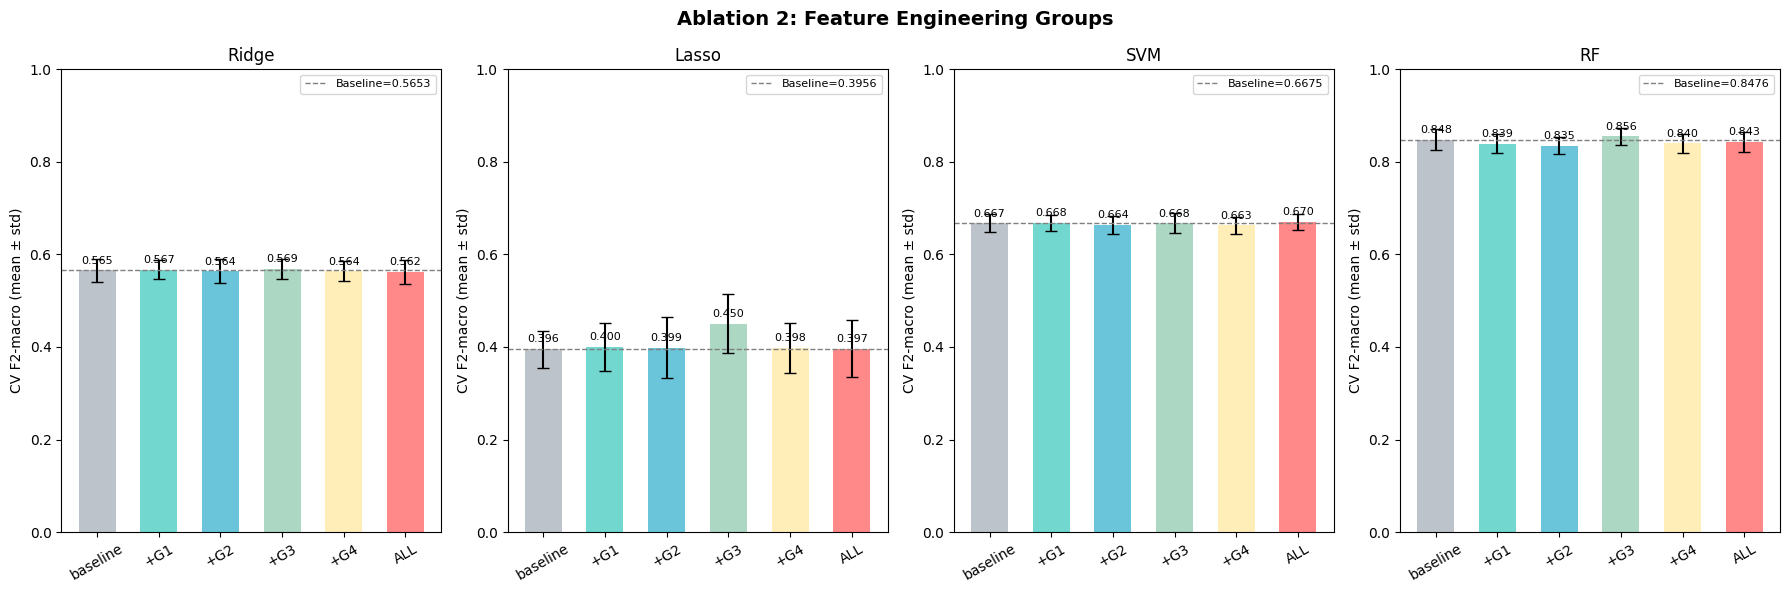


Ablation 2 Summary:
  config model  cv_f2_mean  cv_f2_std  n_features
     +G3 Lasso      0.4502     0.0641          31
     +G1 Lasso      0.3999     0.0522          31
     +G2 Lasso      0.3987     0.0659          31
     +G4 Lasso      0.3981     0.0539          31
     ALL Lasso      0.3965     0.0617          34
baseline Lasso      0.3956     0.0400          30
     +G3    RF      0.8555     0.0186          11
baseline    RF      0.8476     0.0229          10
     ALL    RF      0.8434     0.0221          14
     +G4    RF      0.8404     0.0205          11
     +G1    RF      0.8392     0.0204          11
     +G2    RF      0.8346     0.0182          11
     +G3 Ridge      0.5692     0.0213          31
     +G1 Ridge      0.5672     0.0208          31
baseline Ridge      0.5653     0.0256          30
     +G2 Ridge      0.5638     0.0253          31
     +G4 Ridge      0.5635     0.0214          31
     ALL Ridge      0.5625     0.0259          34
     ALL   SVM      0.6703   

In [26]:
# ================================================================== #
# CELL 7 — Visualize Ablation 2
# ================================================================== #
df_features = ablation.to_dataframe()
df_features = df_features[df_features['experiment'] == 'feature_engineering']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Ablation 2: Feature Engineering Groups', fontsize=14, fontweight='bold')

configs_order = ['baseline', '+G1', '+G2', '+G3', '+G4', 'ALL']
colors = ['#ADB5BD', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#FF6B6B']

for ax, model_name in zip(axes, [ 'Ridge','Lasso','SVM','RF']):
    sub = df_features[df_features['model'] == model_name]
    sub = sub.set_index('config').reindex(configs_order).reset_index()

    bars = ax.bar(
        sub['config'], sub['cv_f2_mean'],
        yerr=sub['cv_f2_std'],
        color=colors, alpha=0.8,
        capsize=4, width=0.6
    )
    # Đường baseline để so sánh
    baseline_val = sub[sub['config'] == 'baseline']['cv_f2_mean'].values[0]
    ax.axhline(baseline_val, color='gray', linestyle='--',
               linewidth=1, label=f'Baseline={baseline_val:.4f}')

    ax.set_title(f'{model_name}', fontsize=12)
    ax.set_ylabel('CV F2-macro (mean ± std)')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

    # Annotate values
    for bar, mean in zip(bars, sub['cv_f2_mean']):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ablation2_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nAblation 2 Summary:")
print(df_features[[
    'config', 'model', 'cv_f2_mean', 'cv_f2_std', 'n_features'
]].sort_values(['model', 'cv_f2_mean'], ascending=[True, False]).to_string(index=False))

In [6]:
# ================================================================== #
# CELL — ABLATION 3: Preprocessing Steps (thay thế cell cũ)
# ================================================================== #
print("\n" + "="*60)
print("ABLATION 3: Preprocessing Steps")
print("="*60)
print("""
Mục đích: Isolate đóng góp của từng bước preprocessing
Configs :
  0: PipelineA baseline
  1: + Feature Engineering
  2: + Scale only (RobustScaler)
  3: + Skew only  (Yeo-Johnson)
  4: + OHE only   (OneHotEncoder)
  5: + Scale + Skew
  6: PipelineB full (không FE)
  7: PipelineB full + FE
Models  : Ridge, Lasso, SVM, RF
Data    : raw_train (preprocessor chạy lại cho từng config)
""")

from src.model.svm_classifier import SVMClassifierModel

# Xóa kết quả dở dang/cũ để chạy lại an toàn sau khi bị ngắt.
ablation.results = [
    result for result in ablation.results
    if result.experiment != 'preprocessing_steps'
]

results_preprocessing = ablation.run_ablation_preprocessing(
    raw_train_df = raw_train,
    models       = {
        'Ridge': RidgeRegressionModel(),
        'Lasso': LassoRegressionModel(),
        'SVM'  : SVMClassifierModel(),
        'RF'   : RandomForestClassifierModel(),
    }
)


ABLATION 3: Preprocessing Steps

Mục đích: Isolate đóng góp của từng bước preprocessing
Configs :
  0: PipelineA baseline
  1: + Feature Engineering
  2: + Scale only (RobustScaler)
  3: + Skew only  (Yeo-Johnson)
  4: + OHE only   (OneHotEncoder)
  5: + Scale + Skew
  6: PipelineB full (không FE)
  7: PipelineB full + FE
Models  : Ridge, Lasso, SVM, RF
Data    : raw_train (preprocessor chạy lại cho từng config)


ABLATION 3 — Preprocessing Steps
  CV: 5 folds × 3 repeats

  Config: Config0_baseline
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[P

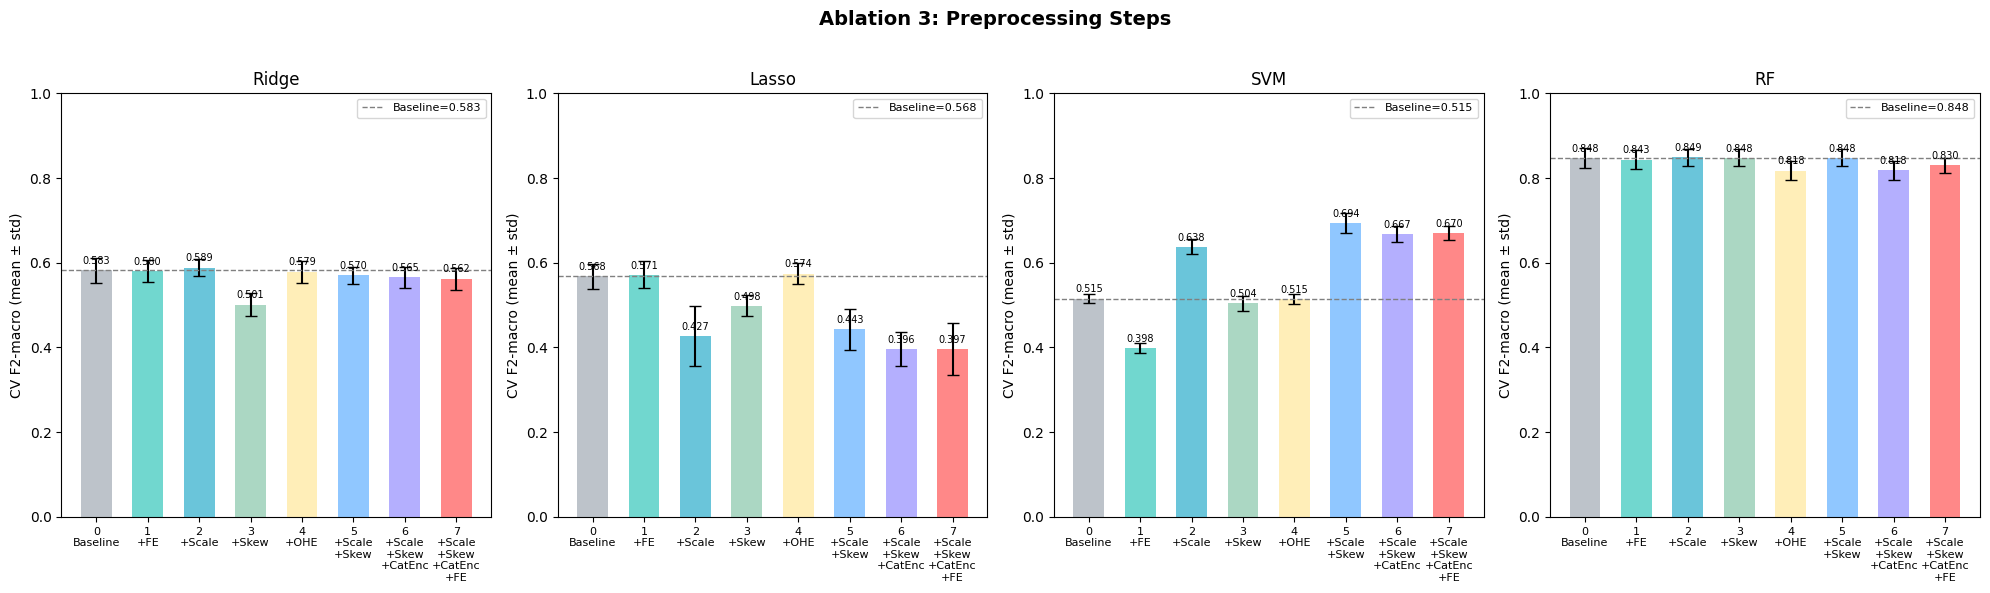


Ablation 3 Summary:


,config,model,cv_f2_mean,cv_f2_std,n_features
0,Config0_baseline,Lasso,0.5682,0.0292,10
1,Config1_+FE,Lasso,0.5713,0.0317,14
2,Config2_+Scale,Lasso,0.4269,0.0709,10
3,Config3_+Skew,Lasso,0.4984,0.0251,10
4,Config4_+OHE,Lasso,0.5743,0.0252,30
5,Config5_+Scale+Skew,Lasso,0.4425,0.0475,10
6,Config6_PipelineB_full,Lasso,0.3956,0.0400,30
7,Config7_PipelineB_full+FE,Lasso,0.3965,0.0617,34
8,Config0_baseline,RF,0.8476,0.0229,10
9,Config1_+FE,RF,0.8434,0.0221,14


In [8]:
# ── Visualize Ablation 3 ─────────────────────────────────────────
df_prep = ablation.to_dataframe()
df_prep = df_prep[df_prep['experiment'] == 'preprocessing_steps'].copy()

configs_order = [
    'Config0_baseline',
    'Config1_+FE',
    'Config2_+Scale',
    'Config3_+Skew',
    'Config4_+OHE',
    'Config5_+Scale+Skew',
    'Config6_PipelineB_full',
    'Config7_PipelineB_full+FE',
]

# Short labels cho dễ đọc
label_map = {
    'Config0_baseline'      : '0\nBaseline',
    'Config1_+FE'           : '1\n+FE',
    'Config2_+Scale'        : '2\n+Scale',
    'Config3_+Skew'         : '3\n+Skew',
    'Config4_+OHE'          : '4\n+OHE',
    'Config5_+Scale+Skew'   : '5\n+Scale\n+Skew',
    'Config6_PipelineB_full': '6\n+Scale\n+Skew\n+CatEnc',
    'Config7_PipelineB_full+FE': '7\n+Scale\n+Skew\n+CatEnc\n+FE',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Ablation 3: Preprocessing Steps', fontsize=14, fontweight='bold')

colors = ['#ADB5BD','#4ECDC4','#45B7D1','#96CEB4',
          '#FFEAA7','#74B9FF','#A29BFE','#FF6B6B']

for ax, model_name in zip(axes, ['Ridge', 'Lasso', 'SVM', 'RF']):
    sub = df_prep[df_prep['model'] == model_name].copy()
    sub = (sub.drop_duplicates('config', keep='last')
              .set_index('config').reindex(configs_order).reset_index())
    available = sub['cv_f2_mean'].notna()

    if not available.any():
        ax.set_visible(False)
        continue

    labels = [label_map[c] for c in sub['config']]
    bars   = ax.bar(
        np.arange(len(labels))[available], sub.loc[available, 'cv_f2_mean'],
        yerr=sub.loc[available, 'cv_f2_std'],
        color=np.array(colors)[available], alpha=0.8,
        capsize=4, width=0.6
    )
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)

    # Baseline reference line
    baseline = sub.loc[
        sub['config'] == 'Config0_baseline', 'cv_f2_mean'
    ].dropna()
    if not baseline.empty:
        ax.axhline(baseline.iloc[0], color='gray', linestyle='--',
                   linewidth=1, label=f'Baseline={baseline.iloc[0]:.3f}')

    ax.set_title(f'{model_name}', fontsize=12)
    ax.set_ylabel('CV F2-macro (mean ± std)')
    ax.set_ylim(0, 1)
    if not baseline.empty:
        ax.legend(fontsize=8)

    # Annotate values
    for bar, mean in zip(bars, sub.loc[available, 'cv_f2_mean']):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=7
        )

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(RESULTS_DIR / 'ablation3_preprocessing.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nAblation 3 Summary:")
display(df_prep[[
    'config', 'model', 'cv_f2_mean', 'cv_f2_std', 'n_features'
]].sort_values(['model', 'config']).reset_index(drop=True))

## Ablation 4: Final Model-Specific Configurations

Vòng xác nhận nhỏ, fold-local, chỉ dùng train data. Mỗi model thử 4 cấu hình đã lọc từ Ablation 1-3.

In [6]:
from src.core.data_preprocessing import PipelineA, PipelineB

# Cho phép chạy lại cell mà không giữ kết quả Ablation 4 cũ.
ablation.results = [
    result for result in ablation.results
    if result.experiment != 'final_configuration'
]

W_RIDGE = {0: 1.0, 1: 1.5, 2: 2.0}
W_RISK  = {0: 1.0, 1: 2.0, 2: 3.0}

final_configs = []

# RF: Pipeline A baseline/G3 x none/SMOTE.
for groups, feature_name in [([], 'base'), (['G3'], 'G3')]:
    for imbalance in ['none', 'smote']:
        final_configs.append({
            'model_name': 'RF',
            'model': RandomForestClassifierModel(),
            'config': f'PA_{feature_name}_{imbalance}',
            'preprocessor_factory': lambda groups=groups: PipelineA(fe_groups=groups),
            'imbalance': imbalance,
        })

# SVM: scale-only/scale+skew x none/risk weights.
for use_skew, prep_name in [(False, 'scale'), (True, 'scale_skew')]:
    for weighted in [False, True]:
        final_configs.append({
            'model_name': 'SVM',
            'model': SVMClassifierModel(),
            'config': f'{prep_name}_{"w123" if weighted else "none"}',
            'preprocessor_factory': lambda use_skew=use_skew: PipelineB(
                fe_groups=[], use_skew=use_skew, use_scale=True, use_ohe=False
            ),
            'imbalance': 'weighted' if weighted else 'none',
            'class_weights': W_RISK if weighted else None,
        })

# Ridge: scale-only baseline/G3 x none/moderate weights.
for groups, feature_name in [([], 'base'), (['G3'], 'G3')]:
    for weighted in [False, True]:
        final_configs.append({
            'model_name': 'Ridge',
            'model': RidgeRegressionModel(),
            'config': f'scale_{feature_name}_{"w1152" if weighted else "none"}',
            'preprocessor_factory': lambda groups=groups: PipelineB(
                fe_groups=groups, use_skew=False, use_scale=True, use_ohe=False
            ),
            'imbalance': 'weighted' if weighted else 'none',
            'class_weights': W_RIDGE if weighted else None,
        })

# Lasso: OHE-only baseline/G3 x none/risk weights.
for groups, feature_name in [([], 'base'), (['G3'], 'G3')]:
    for weighted in [False, True]:
        final_configs.append({
            'model_name': 'Lasso',
            'model': LassoRegressionModel(),
            'config': f'ohe_{feature_name}_{"w123" if weighted else "none"}',
            'preprocessor_factory': lambda groups=groups: PipelineB(
                fe_groups=groups, use_skew=False, use_scale=False, use_ohe=True
            ),
            'imbalance': 'weighted' if weighted else 'none',
            'class_weights': W_RISK if weighted else None,
        })

print(f'Ablation 4 configs: {len(final_configs)}')
results_final = ablation.run_ablation_final_configs(
    raw_train_df=raw_train,
    configs=final_configs,
)

Ablation 4 configs: 16

ABLATION 4 - Final Model-Specific Configurations
  CV: 5 folds x 3 repeats

  [RF] PA_base_none
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[Pipeline

In [7]:
df_final = ablation.to_dataframe()
df_final = df_final[df_final['experiment'] == 'final_configuration'].copy()
df_final = df_final.sort_values(
    ['model', 'cv_f2_mean', 'recall_high', 'cv_f1w_mean'],
    ascending=[True, False, False, False]
)

columns = [
    'model', 'config', 'cv_f2_mean', 'cv_f2_std', 'cv_f1w_mean',
    'recall_low', 'recall_medium', 'recall_high', 'gap', 'n_features'
]
print('Ablation 4 - all configurations')
display(df_final[columns].reset_index(drop=True))

winners = df_final.groupby('model', as_index=False, sort=False).head(1)
print('Ablation 4 - provisional winners by F2-macro')
display(winners[columns].reset_index(drop=True))

df_final.to_csv(RESULTS_DIR / 'ablation4_final_configs.csv', index=False)

Ablation 4 - all configurations


,model,config,cv_f2_mean,cv_f2_std,cv_f1w_mean,recall_low,recall_medium,recall_high,gap,n_features
0,Lasso,ohe_base_none,0.5743,0.0252,0.6553,0.7210,0.3552,0.6500,0.0080,30
1,Lasso,ohe_G3_none,0.5714,0.0239,0.6521,0.7141,0.3631,0.6403,0.0139,31
2,Lasso,ohe_G3_w123,0.5667,0.0155,0.6069,0.5841,0.4763,0.6889,0.0100,31
3,Lasso,ohe_base_w123,0.5663,0.0203,0.6105,0.6019,0.4415,0.7079,0.0083,30
4,RF,PA_base_smote,0.8647,0.0178,0.9105,0.9572,0.8431,0.7808,0.1353,10
5,RF,PA_G3_smote,0.8589,0.0237,0.9023,0.9450,0.8388,0.7850,0.1411,11
6,RF,PA_G3_none,0.8555,0.0186,0.9147,0.9845,0.8140,0.7301,0.1445,11
7,RF,PA_base_none,0.8476,0.0229,0.9097,0.9812,0.8119,0.7143,0.1524,10
8,Ridge,scale_base_none,0.5887,0.0195,0.6459,0.6527,0.4736,0.6772,0.0083,10
9,Ridge,scale_base_w1152,0.5816,0.0221,0.6234,0.6067,0.4829,0.7132,0.0079,10


Ablation 4 - provisional winners by F2-macro


,model,config,cv_f2_mean,cv_f2_std,cv_f1w_mean,recall_low,recall_medium,recall_high,gap,n_features
0,Lasso,ohe_base_none,0.5743,0.0252,0.6553,0.7210,0.3552,0.6500,0.0080,30
1,RF,PA_base_smote,0.8647,0.0178,0.9105,0.9572,0.8431,0.7808,0.1353,10
2,Ridge,scale_base_none,0.5887,0.0195,0.6459,0.6527,0.4736,0.6772,0.0083,10
3,SVM,scale_skew_w123,0.7186,0.0189,0.7886,0.8575,0.6130,0.6931,0.1090,10


## Ablation 4b: Remaining Models

Filtered confirmation cho 7 model còn thiếu. Chạy `fast` trước; chạy `slow` riêng cho Decision Tree và LightGBM scratch. Mỗi batch được lưu CSV riêng để không mất kết quả.

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier
from src.model.decision_tree_classifier import DecisionTreeClassifierModel
from src.model.xgbrf_classifier import XGBRFClassifierModel
from src.model.hist_gradient_boosting_classifier import HistGradientBoostingClassifierModel
from src.model.lgbm_scratch_v2 import LGBMScratchModel
from src.model.linear_regression import LinearRegressionModel
from src.model.huber_regression import HuberRegressionModel

# 'fast': XGB, XGBRF, HistGB, Linear, Huber
# 'decision_tree': chi Decision Tree scratch
# 'lightgbm'     : chi LightGBM scratch
# 'slow'         : ca hai model scratch
# 'all'          : tat ca 7 model trong mot lan chay
ABLATION4B_BATCH = 'slow'

W_MODERATE = {0: 1.0, 1: 1.5, 2: 2.0}

class HistGBNoWeightModel(HistGradientBoostingClassifierModel):
    """HistGB variant without the wrapper's default balanced weight."""
    def build(self, **params):
        cfg = {
            'max_iter': 300, 'learning_rate': 0.05,
            'max_leaf_nodes': 63, 'max_depth': None,
            'min_samples_leaf': 20, 'l2_regularization': 0.0,
            'class_weight': None, 'random_state': self.random_state,
        }
        cfg.update(params)
        self.model = HistGradientBoostingClassifier(**cfg)
        return self

remaining_configs = []

def add_tree_smote_configs(model_name, model_factory):
    for groups, feature_name in [([], 'base'), (['G3'], 'G3')]:
        for imbalance in ['none', 'smote']:
            remaining_configs.append({
                'model_name': model_name,
                'model': model_factory(),
                'config': f'PA_{feature_name}_{imbalance}',
                'preprocessor_factory': lambda groups=groups: PipelineA(fe_groups=groups),
                'imbalance': imbalance,
            })

def add_linear_configs(model_name, model_factory):
    for use_skew, prep_name in [(False, 'scale'), (True, 'scale_skew')]:
        for weighted in [False, True]:
            remaining_configs.append({
                'model_name': model_name,
                'model': model_factory(),
                'config': f'{prep_name}_{"w1152" if weighted else "none"}',
                'preprocessor_factory': lambda use_skew=use_skew: PipelineB(
                    fe_groups=[], use_skew=use_skew,
                    use_scale=True, use_ohe=False
                ),
                'imbalance': 'weighted' if weighted else 'none',
                'class_weights': W_MODERATE if weighted else None,
            })

if ABLATION4B_BATCH in ('fast', 'all'):
    add_tree_smote_configs('XGB', XGBClassifierModel)
    add_tree_smote_configs('XGBRF', XGBRFClassifierModel)

    # HistGB: compare its internal class weighting explicitly.
    for groups, feature_name in [([], 'base'), (['G3'], 'G3')]:
        for model_factory, weight_name in [
            (HistGBNoWeightModel, 'none'),
            (HistGradientBoostingClassifierModel, 'balanced'),
        ]:
            remaining_configs.append({
                'model_name': 'HistGB',
                'model': model_factory(),
                'config': f'PA_{feature_name}_{weight_name}',
                'preprocessor_factory': lambda groups=groups: PipelineA(fe_groups=groups),
                'imbalance': 'none',
            })

    add_linear_configs('Linear', LinearRegressionModel)
    add_linear_configs('Huber', HuberRegressionModel)

if ABLATION4B_BATCH in ('decision_tree', 'slow', 'all'):
    add_tree_smote_configs('DecisionTree', DecisionTreeClassifierModel)
if ABLATION4B_BATCH in ('lightgbm', 'slow', 'all'):
    add_tree_smote_configs('LightGBM', LGBMScratchModel)

valid_batches = {'fast', 'decision_tree', 'lightgbm', 'slow', 'all'}
if ABLATION4B_BATCH not in valid_batches:
    raise ValueError(f'Unknown batch: {ABLATION4B_BATCH}')

batch_models = {spec['model_name'] for spec in remaining_configs}
ablation.results = [
    result for result in ablation.results
    if not (result.experiment == 'final_configuration'
            and result.model in batch_models)
]

batch_path = RESULTS_DIR / f'ablation4_remaining_{ABLATION4B_BATCH}.csv'
print(f'Ablation 4b batch={ABLATION4B_BATCH}: '
      f'{len(remaining_configs)} configs, '
      f'{len(remaining_configs) * ablation.n_splits * ablation.n_repeats} fits')

# Checkpoint after every model so a later failure does not erase earlier work.
results_remaining = []
for model_name in dict.fromkeys(spec['model_name'] for spec in remaining_configs):
    model_configs = [
        spec for spec in remaining_configs if spec['model_name'] == model_name
    ]
    model_results = ablation.run_ablation_final_configs(
        raw_train_df=raw_train,
        configs=model_configs,
    )
    results_remaining.extend(model_results)
    batch_df = pd.DataFrame([result.__dict__ for result in results_remaining])
    batch_df.to_csv(batch_path, index=False)
    print(f'Checkpoint saved after {model_name}: {batch_path}')

Ablation 4b batch=slow: 8 configs, 120 fits

ABLATION 4 - Final Model-Specific Configurations
  CV: 5 folds x 3 repeats

  [DecisionTree] PA_base_none
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 rows, fe_groups=[]...
[PipelineA] done — 10 features
[PipelineA] fitting on 1,896 

In [11]:
# Combine every available Ablation 4 CSV, including batches from earlier sessions.
ablation4_files = sorted(RESULTS_DIR.glob('ablation4_*.csv'))
frames = [pd.read_csv(path) for path in ablation4_files]
if not frames:
    raise FileNotFoundError('No Ablation 4 CSV files found')

df_ablation4_all = (pd.concat(frames, ignore_index=True)
                    .drop_duplicates(['model', 'config'], keep='last'))
df_ablation4_all = df_ablation4_all.sort_values(
    ['model', 'cv_f2_mean', 'recall_high', 'cv_f1w_mean'],
    ascending=[True, False, False, False]
)
winners_all = (df_ablation4_all.groupby('model', as_index=False, sort=False)
               .head(1).reset_index(drop=True))

print('Ablation 4 - winners available so far')
display(winners_all[columns])
winners_all.to_csv(RESULTS_DIR / 'ablation4_all_winners.csv', index=False)

Ablation 4 - winners available so far


,model,config,cv_f2_mean,cv_f2_std,cv_f1w_mean,recall_low,recall_medium,recall_high,gap,n_features
0,DecisionTree,PA_G3_none,0.8903,0.0219,0.9255,0.9590,0.8634,0.8472,0.1097,11
1,HistGB,PA_G3_balanced,0.9056,0.0155,0.9309,0.9540,0.8831,0.8819,0.0944,11
2,Huber,scale_w1152,0.5968,0.0192,0.6394,0.6226,0.5083,0.7195,0.0085,10
3,Lasso,ohe_base_none,0.5743,0.0252,0.6553,0.7210,0.3552,0.6500,0.0080,30
4,LightGBM,PA_G3_none,0.8987,0.0241,0.9274,0.9549,0.8794,0.8587,0.1013,11
5,Linear,scale_w1152,0.6005,0.0175,0.6435,0.6355,0.4866,0.7406,0.0040,10
6,RF,PA_base_smote,0.8647,0.0178,0.9105,0.9572,0.8431,0.7808,0.1353,10
7,Ridge,scale_base_none,0.5887,0.0195,0.6459,0.6527,0.4736,0.6772,0.0083,10
8,SVM,scale_skew_w123,0.7186,0.0189,0.7886,0.8575,0.6130,0.6931,0.1090,10
9,XGB,PA_G3_none,0.8963,0.0189,0.9266,0.9553,0.8787,0.8513,0.1037,11
